# A surrogate model (a simplified, fast model) for financial option pricing

### Content   <a name="content"></a>

1. [Creating a "mini-QuantLib" that uses a Binomial Tree to price options](#1)
2. [Creating a "map" of many different market conditions so the surrogate can learn the patterns](#2)
3. [Teaching the Neural Network the relationship between market conditions (S, T, r, sigma) and the Option Price](#3)
4. [Measure speed of the Surrogate](#4)
5. [Visualise](#5)

## Creating a "mini-QuantLib" that uses a Binomial Tree to price options <a name="1"></a>

In [1]:
import numpy as np
import pandas as pd

def binomial_tree_american_option(S, K, T, r, sigma, N=100, option_type='call'):
    """
    This will be the "Ground Truth" that the surrogate tries to mimic; the 'Slow/High-Fidelity' Model. 
    It calculates the price of an American Option using a Binomial Tree.
    S - Current Stock Price.
    K - Strike Price (the price at which the customer has the right to buy/sell).
    T - Time to Maturity (in years).
    r - Risk-free interest rate (e.g., 0.05 for 5%).
    sigma - Volatility (how much the stock swings).
    N - The number of "steps" in the tree. Higher N means more accuracy but slower code.
    """
    dt = T / N                            # The total time divided into small increments.
    u = np.exp(sigma * np.sqrt(dt))       # How much the stock price increases if the market goes up in one step. "Up Factor"
    d = 1 / u                             # It ensures the tree is symmetrical (if it goes up and then down, it returns to the same price). "Down fadtor"
    a = np.exp(r * dt)                    # This is the risk-neutral growth rate (the "discount" factor).
    
    """
    The Risk-Neutral Probabilities
    "Within the domain of derivatives pricing, 'real-world' probabilities are bypassed in favor of risk-neutral probabilities.
    This framework is utilised to ensure that the resulting option price precludes the possibility of arbitrage,
    thereby maintaining a self-consistent, no-free-lunch equilibrium.

    "Here is the market data, and here is the correct price the Binomial Tree calculated. 
    Learn the relationship so I don't have to run this slow tree ever again."
    """
    p = (a - d) / (u - d)                 # Probability of an Up-move
    q = 1 - p                             # Probability of a Down-move
    
    """
    The "Leaf" stage of the Binomial Tree. 
    It calculates every possible price the stock could reach at the very end of the time period (T).
    The code is using Vectorization (a fast way to do math in Python) to calculate all those final prices at once:
    np.arange(N, -1, -1) creates a list of "Down" steps (e.g., if N=100, it goes 100, 99, 98... 0).
    np.arange(0, N + 1, 1) creates a list of "Up" steps (e.g., 0, 1, 2... 100).
    d**(...) and u**(...)raise the "Down" and "Up" factors to those powers.
    S * ... multiplies these factors by the starting stock price to get the actual dollar values.
    """
    S_tree = S * d**(np.arange(N, -1, -1)) * u**(np.arange(0, N + 1, 1))
    
    """
    Calculating whether the option is "in the money" or "out of the money" based on the final price of the underlying asset.
    np.maximum compares every element in the price array against zero simultaneously.
    It's much faster than writing a for loop to check every possible price outcome.
    """
    if option_type == 'call':                 # A call option gives the holder the right to buy
        V = np.maximum(S_tree - K, 0)         # It’s only valuable if the asset price (S_tree) is higher than the strike price (K)
    else:                                     # A put option gives the holder the right to sell.
        V = np.maximum(K - S_tree, 0)         # It’s only valuable if the asset price is lower than the strike price.
        
    """
    Step backwards through the tree
    
    for j in range(N - 1, -1, -1) startS at the second-to-last step (N-1) and work backward to time step 0. 
    
    V = (p * V[1:] + q * V[:-1]) / a  takes the weighted average of the two possible future prices (V_up and V_down)
    using risk-neutral probabilities (p and q) and discounts them back to the current node using a discount factor (a).
    V[1:] - the "up" nodes; V[:-1] - the "down" nodes.

    S * d**(np.arange(j, -1, -1)) * u**(np.arange(0, j + 1, 1)) is a vectorized way to rebuild the stock price tree for that specific time step. 
    It calculates every possible price the stock could be at time j so you can compare it to the option value.
    
    np.maximum(V, Payoff) defining feature of an American Option. 
    Unlike European options (which can only be exercised at the end), American options can be exercised at any time.
    V - the value of waiting (Continuation Value).
    S_tree-K - the value of exercising right now (Intrinsic Value).
    The code chooses the maximum of the two at every single node in the tree.
    
    """

    
    for j in range(N - 1, -1, -1):                                            
        V = (p * V[1:] + q * V[:-1]) / a                                      
        S_tree = S * d**(np.arange(j, -1, -1)) * u**(np.arange(0, j + 1, 1))
        if option_type == 'call':
            V = np.maximum(V, S_tree - K)
        else:
            V = np.maximum(V, K - S_tree)
            
    return V[0]

# Test it
print(f"Option Test Price: {binomial_tree_american_option(100, 100, 1, 0.05, 0.2, option_type='put'):.2f}")

Option Test Price: 6.08


[<a href="#content">Back to top</a>]

## Creating a "map" of many different market conditions so the surrogate can learn the patterns <a name="2"></a>

In [2]:
def generate_dataset(n_samples=1000):
    data = []
    for _ in range(n_samples):
        # Random market conditions
        S = np.random.uniform(80, 120)      # Stock price
        K = 100                             # Strike price (fixed for simplicity)
        T = np.random.uniform(0.1, 2.0)     # Time to expiry (years)
        r = np.random.uniform(0.01, 0.10)   # Risk-free rate (1% to 10%)
        sigma = np.random.uniform(0.1, 0.5) # Volatility (10% to 50%)
        
        # Calculate the "True" price using our slow model
        price = binomial_tree_american_option(S, K, T, r, sigma, option_type='put')
        
        data.append([S, T, r, sigma, price])
        
    return pd.DataFrame(data, columns=['S', 'T', 'r', 'sigma', 'Price'])

# Create 1000 samples for our research
df = generate_dataset(1000)
print(df.head())

            S         T         r     sigma      Price
0   95.920955  1.672512  0.068265  0.429476  18.695040
1  119.523952  0.517769  0.032789  0.317306   2.712321
2  112.355928  0.619601  0.091996  0.156456   0.520479
3  115.361314  1.709616  0.087076  0.381134   9.530869
4  100.446863  1.051226  0.051938  0.116841   2.853643


[<a href="#content">Back to top</a>]

## Teaching the Neural Network the relationship between market conditions (S, T, r, sigma) and the Option Price <a name="3"></a>

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import time

# 1. Prepare the Data
# X = Inputs (Features), y = Output (Target Price)
X = df[['S', 'T', 'r', 'sigma']]
y = df['Price']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature Scaling (CRITICAL for Neural Networks)
# NNs hate raw numbers; they prefer data centered around 0.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

# 3. Create the "Deep Surrogate"
# Use 3 hidden layers with 100 neurons each. 
# 'relu' is the standard activation function for non-linear finance problems.
surrogate = MLPRegressor(hidden_layer_sizes=(100, 100, 100), 
                         activation='relu', 
                         solver='adam', 
                         max_iter=1000, 
                         random_state=42)

# 4. Train the Model (The "Learning" Phase)
print("Training the surrogate... please wait.")
surrogate.fit(X_train_scaled, y_train)
print("Training complete!")

Training the surrogate... please wait.
Training complete!


[<a href="#content">Back to top</a>]

## Measure speed of the Surrogate <a name="4"></a>

In [4]:
start_time = time.time()
y_pred = surrogate.predict(X_test_scaled)
end_time = time.time()

surrogate_speed = (end_time - start_time) / len(X_test)

# Calculate Accuracy Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- RESEARCH RESULTS ---")
print(f"Accuracy (R² Score): {r2:.4f}") # 1.000 is perfect
print(f"Average Error: {mae:.4f}")
print(f"Speed per prediction: {surrogate_speed:.8f} seconds")

--- RESEARCH RESULTS ---
Accuracy (R² Score): 0.9996
Average Error: 0.1053
Speed per prediction: 0.00000500 seconds


[<a href="#content">Back to top</a>]

## Visualise <a name="5"></a>

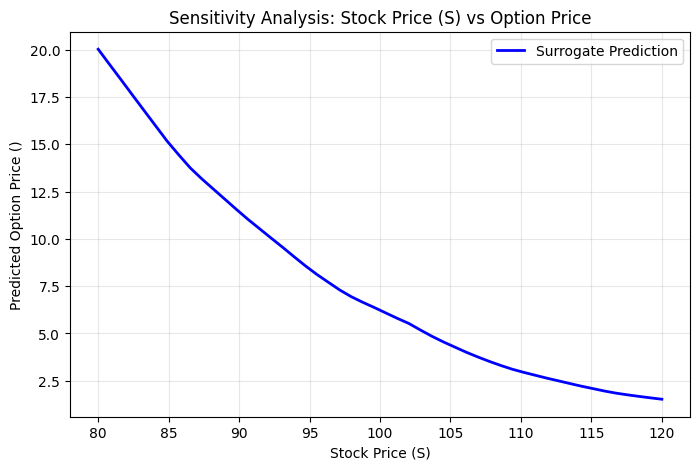

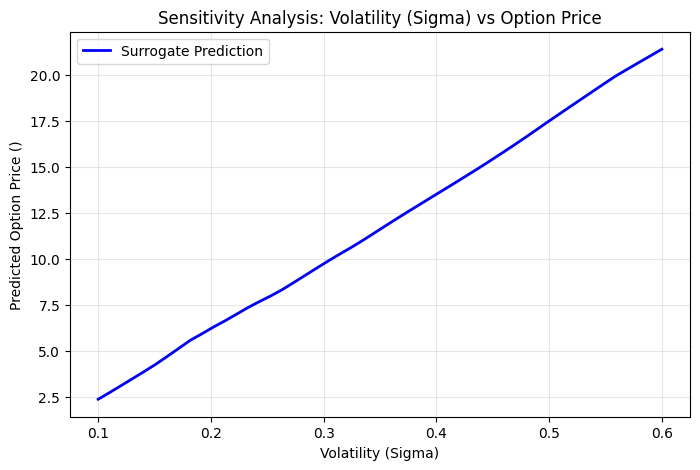

In [5]:
import matplotlib.pyplot as plt

def plot_sensitivity(model, scaler, base_input, feature_idx, feature_name, scan_range):
    """
    model: The trained surrogate
    scaler: The StandardScaler used during training
    base_input: A 'typical' market scenario (e.g., [100, 1.0, 0.05, 0.2])
    feature_idx: Which column to change (0=S, 1=T, 2=r, 3=sigma)
    """
    # Create a range of values for the feature we want to test
    scan_values = np.linspace(scan_range[0], scan_range[1], 50)
    test_inputs = np.tile(base_input, (50, 1))
    test_inputs[:, feature_idx] = scan_values
    
    # Scale and Predict
    test_inputs_scaled = scaler.transform(test_inputs)
    predictions = model.predict(test_inputs_scaled)
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(scan_values, predictions, 'b-', linewidth=2, label='Surrogate Prediction')
    plt.title(f'Sensitivity Analysis: {feature_name} vs Option Price')
    plt.xlabel(feature_name)
    plt.ylabel('Predicted Option Price ()')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Define a "Standard" market scenario: S=100, T=1yr, r=5%, Sigma=20%
base_scenario = np.array([[100, 1.0, 0.05, 0.2]])

# 1. Plot sensitivity to Stock Price (S)
plot_sensitivity(surrogate, scaler, base_scenario, 0, 'Stock Price (S)', [80, 120])

# 2. Plot sensitivity to Volatility (Sigma)
plot_sensitivity(surrogate, scaler, base_scenario, 3, 'Volatility (Sigma)', [0.1, 0.6])